<a href="https://colab.research.google.com/github/maps-05/portfolio/blob/main/DataClustering_employee_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Data Clustering Analysis

NAME: RELATIVO, Muffle P

SECTION: BsCpE 4-GE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/personnel_data.csv')
df.head()



,EmployeeID,Age,Experience,EducationLevel,Salary,JobSatisfaction,Department,ProjectsHandled,PromotionLast5Years
0,1,50,1,2,33.07,3,5,10,0
1,2,36,4,1,19.37,7,1,11,0
2,3,29,28,1,52.64,8,1,5,1
3,4,42,18,3,60.37,10,4,8,0
4,5,40,7,1,28.94,6,3,15,0


In [ ]:
# Drop Employee_ID and Department
df_cleaned = df.drop(columns=['EmployeeID', 'Department'])
df_cleaned

,Age,Experience,EducationLevel,Salary,JobSatisfaction,ProjectsHandled,PromotionLast5Years
0,50,1,2,33.07,3,10,0
1,36,4,1,19.37,7,11,0
2,29,28,1,52.64,8,5,1
3,42,18,3,60.37,10,8,0
4,40,7,1,28.94,6,15,0
...,...,...,...,...,...,...,...
495,59,7,2,35.53,2,0,0
496,28,0,2,31.77,8,5,0
497,34,2,2,33.01,5,5,0
498,30,23,2,52.72,7,20,0


In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_df = df_cleaned.select_dtypes(include=[np.number]).copy()

# Initialize scaler
scaler = StandardScaler()

# Fit-transform
scaled_data = scaler.fit_transform(numeric_df)
scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns)
scaled_salary_125 = scaled_df.loc[124, 'Salary']

scaled_experience_130 = scaled_df.loc[129, 'Experience']

print("Scaled Salary of data 125:", scaled_salary_125)
print("Scaled Experience of data 130:", scaled_experience_130)

Scaled Salary of data 125: 0.11263172953612322
Scaled Experience of data 130: -1.2543169481899312


In [ ]:
# Calculate the correlation matrix

correlation_matrix = df_cleaned.corr()
correlation_matrix

,Age,Experience,EducationLevel,Salary,JobSatisfaction,ProjectsHandled,PromotionLast5Years
Age,1.000000,-0.009887,-0.073172,-0.057021,-0.048376,0.059960,-0.026902
Experience,-0.009887,1.000000,-0.041060,0.686259,-0.009742,0.003324,-0.020027
EducationLevel,-0.073172,-0.041060,1.000000,0.645446,0.033241,0.006041,0.002954
Salary,-0.057021,0.686259,0.645446,1.000000,-0.009889,0.009303,-0.009194
JobSatisfaction,-0.048376,-0.009742,0.033241,-0.009889,1.000000,-0.003085,-0.033296
ProjectsHandled,0.059960,0.003324,0.006041,0.009303,-0.003085,1.000000,-0.007724
PromotionLast5Years,-0.026902,-0.020027,0.002954,-0.009194,-0.033296,-0.007724,1.000000


In [ ]:
corr_matrix = scaled_df.corr()

threshold = 0.66
high_corr = []

for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if col != row and abs(corr_matrix.loc[row, col]) > threshold:
            high_corr.append((row, col, corr_matrix.loc[row, col]))

# Convert to DataFrame for readability
high_corr_df = pd.DataFrame(high_corr, columns=['Variable 1','Variable 2','Correlation']).drop_duplicates()

print("Highly correlated variables:")
print(high_corr_df)

Highly correlated variables:
   Variable 1  Variable 2  Correlation
0      Salary  Experience     0.686259
1  Experience      Salary     0.686259


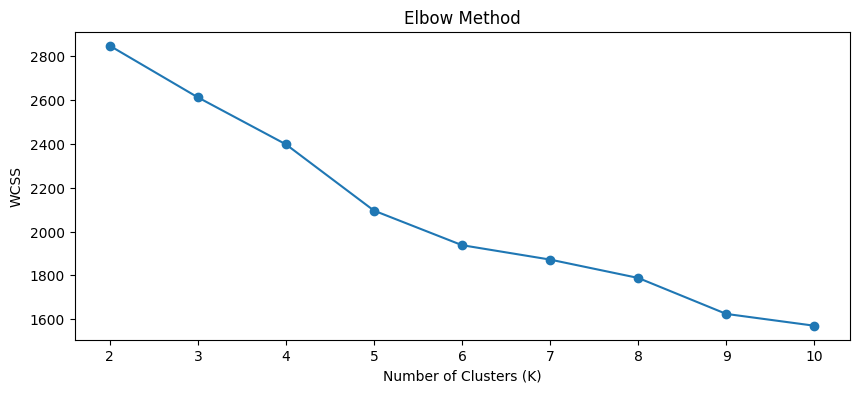

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=101, n_init='auto')
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(scaled_df, kmeans.labels_))

# Plot Elbow Graph
plt.figure(figsize=(10,4))
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [ ]:
final_model = KMeans(n_clusters = 5, random_state = 101, n_init = 'auto')
scaled_df['Cluster'] = final_model.fit_predict(scaled_df)
scaled_df


,Age,Experience,EducationLevel,Salary,JobSatisfaction,ProjectsHandled,PromotionLast5Years,Cluster
0,0.786010,-1.536991,-0.202539,-1.112326,-0.885324,0.009972,-0.506242,1
1,-0.482040,-1.254317,-1.452777,-1.872376,0.525551,0.170806,-0.506242,1
2,-1.116065,1.007072,-1.452777,-0.026618,0.878270,-0.794201,1.975338,4
3,0.061410,0.064826,1.047700,0.402228,1.583708,-0.311697,-0.506242,3
4,-0.119740,-0.971643,-1.452777,-1.341450,0.172832,0.814145,-0.506242,1
...,...,...,...,...,...,...,...,...
495,1.601185,-0.971643,-0.202539,-0.975849,-1.238043,-1.598374,-0.506242,1
496,-1.206640,-1.631215,-0.202539,-1.184447,0.878270,-0.794201,-0.506242,1
497,-0.663190,-1.442766,-0.202539,-1.115654,-0.179887,-0.794201,-0.506242,1
498,-1.025490,0.535949,-0.202539,-0.022180,0.525551,1.618318,-0.506242,0


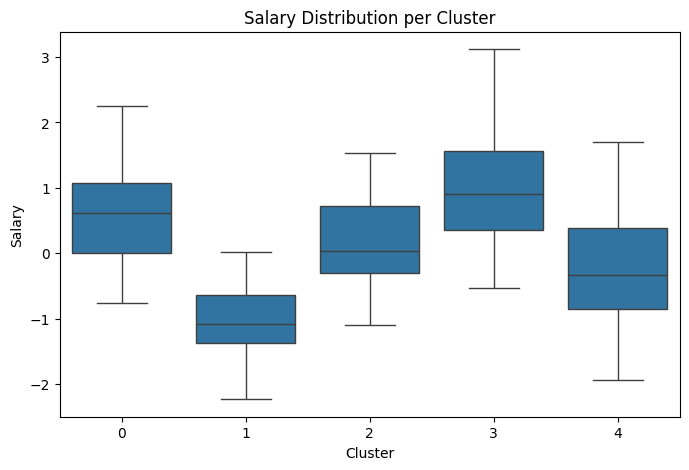

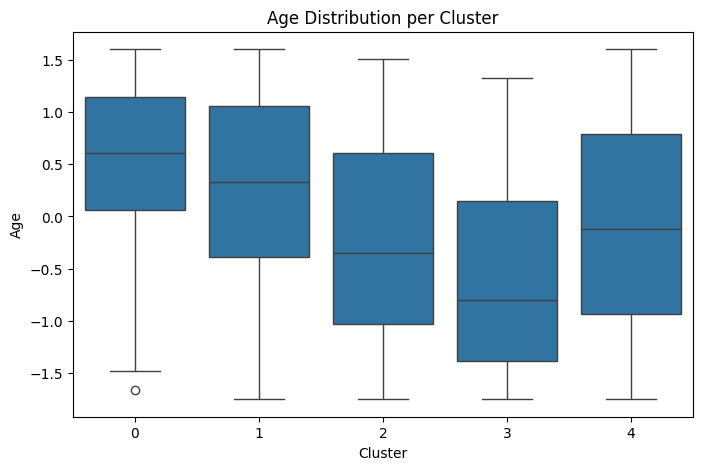


Cluster with the higher Salary: Cluster 3
Cluster with the higher Age: Cluster 0


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Salary', data=scaled_df)
plt.title("Salary Distribution per Cluster")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Age', data=scaled_df)
plt.title("Age Distribution per Cluster")
plt.show()
cluster_means = scaled_df.groupby('Cluster')[['Salary', 'Age']].mean()

# Identify clusters with highest values
highest_salary_cluster = cluster_means['Salary'].idxmax()
highest_age_cluster = cluster_means['Age'].idxmax()

print(f"\nCluster with the higher Salary: Cluster {highest_salary_cluster}")
print(f"Cluster with the higher Age: Cluster {highest_age_cluster}")


In [ ]:
import plotly.graph_objects as go

data305_cluster = scaled_df.loc[304, 'Cluster']
print("Q8. Data 305 belongs to Cluster:", data305_cluster)

centroids = final_model.cluster_centers_
age_salary_centroids = centroids[:, [scaled_df.columns.get_loc('Age'),
                                     scaled_df.columns.get_loc('Salary')]]

print("\nQ9. Centroids of Age & Salary (scaled):")
for i, c in enumerate(age_salary_centroids):
    print(f"Cluster {i}: {c.tolist()}")

age_salary_corr = scaled_df[['Age','Salary']].corr().iloc[0,1]
print("\nQ10. Correlation between Age & Salary:", age_salary_corr)

fig = go.Figure()

# Plot cluster points
fig.add_trace(go.Scatter3d(
    x=scaled_df['Age'],
    y=scaled_df['Salary'],
    z=scaled_df['JobSatisfaction'],
    mode='markers',
    marker=dict(size=5, color=scaled_df['Cluster'], colorscale='Viridis', opacity=0.6),
    name="Employees"
))

fig.add_trace(go.Scatter3d(
    x=[scaled_df.loc[304, 'Age']],
    y=[scaled_df.loc[304, 'Salary']],
    z=[scaled_df.loc[304, 'JobSatisfaction']],
    mode='markers',
    marker=dict(size=10, color='black', symbol='circle'),
    name="Data 305"
))

fig.add_trace(go.Scatter3d(
    x=centroids[:, scaled_df.columns.get_loc('Age')],
    y=centroids[:, scaled_df.columns.get_loc('Salary')],
    z=centroids[:, scaled_df.columns.get_loc('JobSatisfaction')],
    mode='markers',
    marker=dict(size=12, color='black', symbol='x'),
    name="Centroids"
))

# Layout
fig.update_layout(
    title="Interactive 3D Scatter: Age, Salary, Job Satisfaction",
    scene=dict(
        xaxis_title="Age (scaled)",
        yaxis_title="Salary (scaled)",
        zaxis_title="Job Satisfaction (scaled)"
    ),
    legend=dict(x=0, y=1)
)

fig.show()


Q8. Data 305 belongs to Cluster: 0

Q9. Centroids of Age & Salary (scaled):
Cluster 0: [0.49578020013466, 0.6141780199317478]
Cluster 1: [0.20868061786505182, -1.0406996108582804]
Cluster 2: [-0.20091582513802103, 0.16119604136922133]
Cluster 3: [-0.6179025503279312, 1.0363282406422374]
Cluster 4: [-0.05518136450310969, -0.1769641862251638]

Q10. Correlation between Age & Salary: -0.05702129998492703


## Conclusion

It performed a K-Means clustering analysis on employee data after standardizing the numerical features. The `Elbow Method` was used to determine the optimal number of clusters, leading to the selection of 5 clusters. The analysis revealed that `Salary` and `Experience` are highly correlated. After clustering, it was observed that Cluster 3 had the highest average salary, and Cluster 0 had the highest average age. A 3D interactive plot further visualized the distribution of employees across clusters based on `Age`, `Salary`, and `Job Satisfaction`.